In [4]:
import joblib

import umap
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import pandas as pd
 
from sklearn.metrics import label_ranking_average_precision_score

from birdclef_2026_ml.processing.memmap_dataset import load_memmap_dataset, load_ovr_inference_memmap
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.paths import load_project_paths
from birdclef_2026_ml.configs import artifact_stem
from birdclef_2026_ml.training.eval import safe_multilabel_roc_auc, safe_singlelabel_average_precision
from birdclef_2026_ml.models.hierarchical import combine_soft_proba

paths = load_project_paths()

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
def print_metrics(y_true, y_proba, classes):
    roc_auc = safe_multilabel_roc_auc(y_true, y_proba)[0]
    macro_ap = safe_singlelabel_average_precision(y_true, y_proba, classes)
    lrap = label_ranking_average_precision_score(y_true, y_proba)

    print(f"{'Macro ROC-AUC:':30s} {roc_auc:.4f}")
    print(f"{'Macro Average Precision:':30s} {macro_ap:.4f}")
    print(f"{'LRAP:':30s} {lrap:.4f}")
    print()

In [16]:
le_class_name = joblib.load(paths.label_encoders_dir / "class_name.joblib")
le_primary_label = joblib.load(paths.label_encoders_dir / "primary_label.joblib")

primary_to_class = le_class_name.inverse_transform(np.load(paths.primary_to_class / "primary_to_class.npy"))

## 5 seconds chunks

In [17]:
run_name = "run_chunks_overlap"
experiment_name = "sgd_baseline"

dataset = load_memmap_dataset(run_name=run_name, reduced=True, soundscape=True)
experiment_dir = paths.experiment_dir(run_name, experiment_name)

raw_soft_proba = np.load(experiment_dir / "soundscapes" / "combined_proba.npy")
adapted_soft_proba = np.load(experiment_dir / "soundscapes" / "oof_proba.npy")

true_primary_label = dataset.y[:, 1, :]

In [23]:
classes = np.arange(len(le_primary_label.classes_))
print_metrics(true_primary_label, raw_soft_proba, classes)
print_metrics(true_primary_label, adapted_soft_proba, classes)

Macro ROC-AUC:                 0.6253
Macro Average Precision:       0.1329
LRAP:                          0.1248

Macro ROC-AUC:                 0.7398
Macro Average Precision:       0.2788
LRAP:                          0.1014



## MIL

In [35]:
run_name = "run_mil"
experiment_name = "sgd_baseline"

dataset_mil = load_memmap_dataset(run_name=run_name, reduced=True, soundscape=True)
experiment_dir = paths.experiment_dir(run_name, experiment_name)

# raw_soft_proba = np.load(experiment_dir / "soundscapes" / "combined_proba.npy")
# adapted_soft_proba = np.load(experiment_dir / "soundscapes" / "oof_proba.npy")

In [37]:
dataset.filenames

array(['BC2026_Train_0039_S22_20211231_201500.ogg',
       'BC2026_Train_0039_S22_20211231_201500.ogg',
       'BC2026_Train_0039_S22_20211231_201500.ogg',
       'BC2026_Train_0039_S22_20211231_201500.ogg',
       'BC2026_Train_0039_S22_20211231_201500.ogg',
       'BC2026_Train_0039_S22_20211231_201500.ogg',
       'BC2026_Train_0039_S22_20211231_201500.ogg',
       'BC2026_Train_0039_S22_20211231_201500.ogg',
       'BC2026_Train_0039_S22_20211231_201500.ogg',
       'BC2026_Train_0039_S22_20211231_201500.ogg',
       'BC2026_Train_0039_S22_20211231_201500.ogg',
       'BC2026_Train_0039_S22_20211231_201500.ogg',
       'BC2026_Train_0019_S22_20211104_200000.ogg',
       'BC2026_Train_0019_S22_20211104_200000.ogg',
       'BC2026_Train_0019_S22_20211104_200000.ogg',
       'BC2026_Train_0019_S22_20211104_200000.ogg',
       'BC2026_Train_0019_S22_20211104_200000.ogg',
       'BC2026_Train_0019_S22_20211104_200000.ogg',
       'BC2026_Train_0019_S22_20211104_200000.ogg',
       'BC20

In [29]:
adapted_mil_proba = np.load(experiment_dir / "soundscapes" / "sgdclassifier_ovr_mil_second_stage_primary_soundscape_context_oof.npy")
print_metrics(true_primary_label, adapted_mil_proba, classes)

Macro ROC-AUC:                 0.7515
Macro Average Precision:       0.2927
LRAP:                          0.2919



In [50]:
mask = np.array([true_primary_label[:10].astype(bool)])[0]
mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(10, 234))

<Axes: >

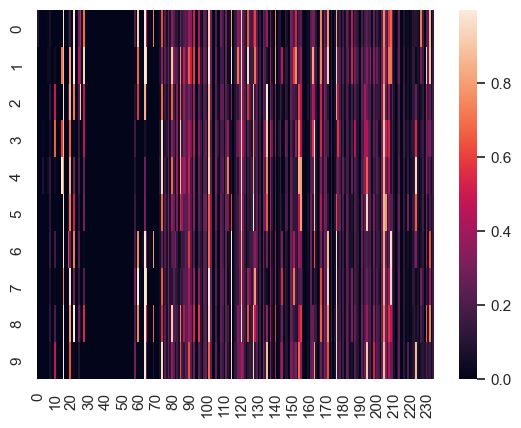

In [52]:
sns.heatmap(adapted_mil_proba[:10])

<Axes: >

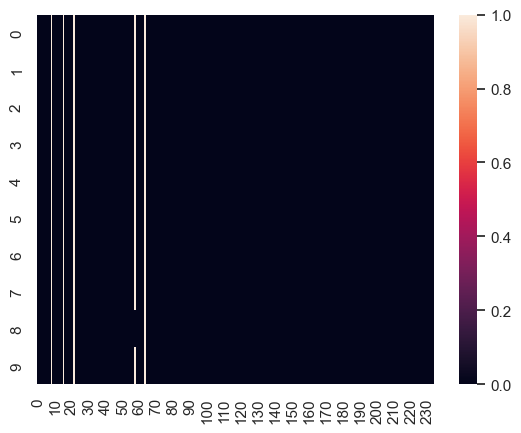

In [ ]:
sns.heatmap(true_primary_label[:10, :70])

[memmap([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]], shape=(10, 234))]